In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional

In [2]:

# Preprocessing function
def clean_text(text):
    if not isinstance(text, str):
        return str(text)
    text = re.sub('[ሃኅኃሐሓኻ]', 'ሀ', text)
    text = re.sub('[ሑኁዅ]', 'ሁ', text)
    text = re.sub('[ኂሒኺ]', 'ሂ', text)
    text = re.sub('[ኌሔዄ]', 'ሄ', text)
    text = re.sub('[ሕኅ]', 'ህ', text)
    text = re.sub('[ኆሖኾ]', 'ሆ', text)
    text = re.sub('[ሠ]', 'ሰ', text)
    text = re.sub('[ሡ]', 'ሱ', text)
    text = re.sub('[ሢ]', 'ሲ', text)
    text = re.sub('[ሣ]', 'ሳ', text)
    text = re.sub('[ሤ]', 'ሴ', text)
    text = re.sub('[ሥ]', 'ስ', text)
    text = re.sub('[ሦ]', 'ሶ', text)
    text = re.sub('[ዓኣዐ]', 'አ', text)
    text = re.sub('[ዑ]', 'ኡ', text)
    text = re.sub('[ዒ]', 'ኢ', text)
    text = re.sub('[ዔ]', 'ኤ', text)
    text = re.sub('[ዕ]', 'እ', text)
    text = re.sub('[ዖ]', 'ኦ', text)
    text = re.sub('[ጸ]', 'ፀ', text)
    text = re.sub('[ጹ]', 'ፁ', text)
    text = re.sub('[ጺ]', 'ፂ', text)
    text = re.sub('[ጻ]', 'ፃ', text)
    text = re.sub('[ጼ]', 'ፄ', text)
    text = re.sub('[ጽ]', 'ፅ', text)
    text = re.sub('[ጾ]', 'ፆ', text)
    text = re.sub('(ሉ[ዋአ])', 'ሏ', text)
    text = re.sub('(ሙ[ዋአ])', 'ሟ', text)
    text = re.sub('(ቱ[ዋአ])', 'ቷ', text)
    text = re.sub('(ሩ[ዋአ])', 'ሯ', text)
    text = re.sub('(ሱ[ዋአ])', 'ሷ', text)
    text = re.sub('(ሹ[ዋአ])', 'ሿ', text)
    text = re.sub('(ቁ[ዋአ])', 'ቋ', text)
    text = re.sub('(ቡ[ዋአ])', 'ቧ', text)
    text = re.sub('(ቹ[ዋአ])', 'ቿ', text)
    text = re.sub('(ሁ[ዋአ])', 'ኋ', text)
    text = re.sub('(ኑ[ዋአ])', 'ኗ', text)
    text = re.sub('(ኙ[ዋአ])', 'ኟ', text)
    text = re.sub('(ኩ[ዋአ])', 'ኳ', text)
    text = re.sub('(ዙ[ዋአ])', 'ዟ', text)
    text = re.sub('(ጉ[ዋአ])', 'ጓ', text)
    text = re.sub('(ደ[ዋአ])', 'ዷ', text)
    text = re.sub('(ጡ[ዋአ])', 'ጧ', text)
    text = re.sub('(ጩ[ዋአ])', 'ጯ', text)
    text = re.sub('(ጹ[ዋአ])', 'ጿ', text)
    text = re.sub('(ፉ[ዋአ])', 'ፏ', text)
    text = re.sub('[ቊ]', 'ቁ', text)  # ቁ can be written as ቊ
    text = re.sub('[ኵ]', 'ኩ', text)  # ኩ can be also written as ኵ
    text = re.sub('[\!\@\#\$\%\^\«\»\&\*\(\)\…\[\]\{\}\;\“\”\›\’\‘\"\'\:\,\‹\/\<\>\?\|\`\´\~\-\=\+\፡\።\፤\;\፦\፥\፧\፣\"]', '', text)

    return text

In [3]:
# Common Amharic stop words
stop_words = [
    "እኔ", "የእኔ", "እኔ ራሴ", "እኛ", "የእኛ", "የእኛ", "እኛ ራሳችን", "አንቺ", "ያንተ", "ራስህን",
    "እራሳችሁ", "እሱ", "የእሱ", "ራሱ", "እሷ", "የእሷ", "እራሷ", "እነሱ", "እነሱን", "የእነሱ", "ራሳቸው",
    "ምንድን", "የትኛው", "ማን", "ይህ", "የሚል ነው", "እነዚህ", "እነዚያ",
    "ነኝ", "ነው", "ናቸው", "ነበር", "ነበሩ", "ሁን", "ቆይቷል", "መሆን", "አላቸው", "አለው",
    "ነበረው", "ያለው", "መ ስ ራ ት", "ያደርጋል", "አደረገ", "ማድረግ", "አንድ", "የ", "እና", "ግን",
    "ከሆነ", "ወይም", "ምክንያቱም", "እንደ", "እስከ", "እያለ", "የ", "ለ", "ጋር", "ስለ", "ላይ",
    "መካከል", "ወደ", "በኩል", "ወቅት", "ከዚህ በፊት", "በኋላ", "ከላይ", "ከታች", "ወደከ", "ወደ ላይ",
    "ታች", "ውስጥ", "ውጭ", "ላይ", "ጠፍቷል", "በላይ", "በታች", "እንደገና", "ተጨማሪ", "ከዚያ",
    "አንድ ጊዜ", "እዚህ", "እዚያ", "መቼ", "የት", "እንዴት", "እንዴት", "ሁሉም", "ማንኛውም", "ሁለቱም",
    "እያንዳንዳቸው", "ጥቂቶች", "ተጨማሪ", "በጣም", "ሌላ", "አንዳንድ", "እንደዚህ", "አይ", "ወይም",
    "አይደለም", "አይደለም", "ብቻ", "የራሱ", "ተመሳሳይ", "ስለዚህ", "ይልቅ", "እንዲሁ", "በጣም",
    "ት", "ይችላል", "ያደርጋል", "ብቻ", "ይገባል", "አሁን."
]

def remove_stop_words(text, stop_words):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)



In [4]:
# Load the dataset
dataset = pd.read_csv("dataset_crop.csv")

# Preprocess the data
dataset['Question'] = dataset['Question'].apply(clean_text)
dataset['Answer'] = dataset['Answer'].apply(clean_text)

In [5]:
# Remove stop words
dataset['Question'] = dataset['Question'].apply(lambda x: remove_stop_words(x, stop_words))
dataset['Answer'] = dataset['Answer'].apply(lambda x: remove_stop_words(x, stop_words))

In [6]:
# Encode labels
label_encoder = LabelEncoder()
dataset['Label'] = label_encoder.fit_transform(dataset['Label'])

In [7]:
# Tokenization
tokenizer_a = Tokenizer()
tokenizer_a.fit_on_texts(dataset['Answer'])
y = tokenizer_a.texts_to_sequences(dataset['Answer'])
y = pad_sequences(y, maxlen=100, padding='post')

In [8]:
# Tokenization
tokenizer = Tokenizer()
tokenizer.fit_on_texts(dataset['Question'])
X = tokenizer.texts_to_sequences(dataset['Question'])
X = pad_sequences(X, maxlen=100, padding='post')

In [9]:
# Get and display tokenized words in the desired format
tokenized_word = ", ".join([f'"{word}"' for word in tokenizer.word_index])



In [10]:
len(tokenizer.word_index)+1 #vocab_size

2228

In [10]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, dataset['Label'], test_size=0.2, random_state=42)

In [27]:
from gensim.models import Word2Vec

# Train Word2Vec model
sentences = [text.split() for text in dataset['Question']]
word2vec_model = Word2Vec(sentences, vector_size=128, window=5, min_count=1, workers=4)

# Save Word2Vec model
word2vec_model.save("word2vec_model.bin")

In [34]:
similar_words = word2vec_model.wv.most_similar('መትከል', topn=10)


In [28]:
# Create embedding matrix
embedding_matrix = np.zeros((len(tokenizer.word_index) + 1, 128))
for word, i in tokenizer.word_index.items():
    if word in word2vec_model.wv:
        embedding_matrix[i] = word2vec_model.wv[word]

In [29]:
# Define the model
model = Sequential()
model.add(Embedding(len(tokenizer.word_index) + 1, 128, weights=[embedding_matrix], input_length=100, trainable=False))
model.add(Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.2)))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(12, activation='softmax'))


In [ ]:

# Compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Define early stopping to prevent overfitting
#early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=64, validation_data=(X_test, y_test))

# Save the model
model.save("crop_chatbot_model_regu.h5")


Epoch 1/100
203/203 [==============================] - 100s 430ms/step - loss: 7.0865 - accuracy: 0.1632 - val_loss: 5.0870 - val_accuracy: 0.1989
Epoch 2/100
203/203 [==============================] - 38s 187ms/step - loss: 4.8713 - accuracy: 0.2270 - val_loss: 4.6695 - val_accuracy: 0.2617
Epoch 3/100
203/203 [==============================] - 38s 185ms/step - loss: 4.3623 - accuracy: 0.2812 - val_loss: 4.3138 - val_accuracy: 0.3123
Epoch 4/100
203/203 [==============================] - 36s 179ms/step - loss: 3.8529 - accuracy: 0.3574 - val_loss: 3.9072 - val_accuracy: 0.3595
Epoch 5/100
203/203 [==============================] - 39s 190ms/step - loss: 3.3950 - accuracy: 0.4294 - val_loss: 3.5175 - val_accuracy: 0.4401
Epoch 6/100
203/203 [==============================] - 38s 186ms/step - loss: 2.9567 - accuracy: 0.5259 - val_loss: 3.1202 - val_accuracy: 0.5239
Epoch 7/100
203/203 [==============================] - 37s 183ms/step - loss: 2.5380 - accuracy: 0.6233 - val_loss: 2.7257 

In [2]:
# # Evaluate the model
# accuracy = model.evaluate(X_test, y_test)
# accuracy

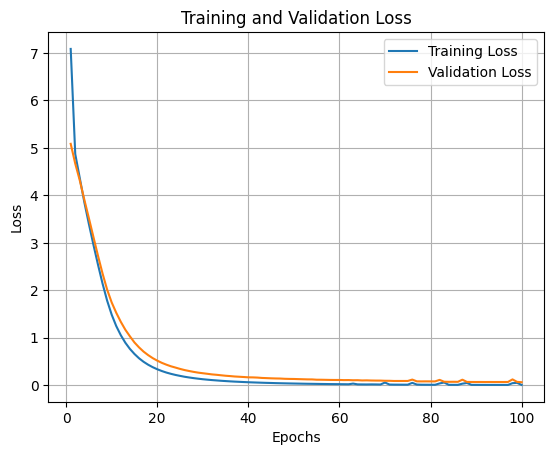

In [ ]:
import matplotlib.pyplot as plt

# Get the training history from the model.fit() method
history = model.history.history

# Extract loss values from the history
training_loss = history['loss']
validation_loss = history['val_loss']

# Create a list of epochs for the x-axis
epochs_list = range(1, epochs + 1)

# Plot the loss graph
plt.plot(epochs_list, training_loss, label='Training Loss')
plt.plot(epochs_list, validation_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


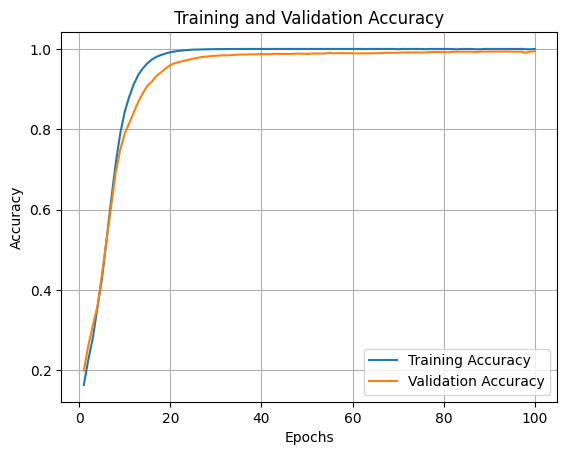

In [ ]:
import matplotlib.pyplot as plt

# Get the training history from the model.fit() method
history = model.history.history

# Extract accuracy values from the history
training_accuracy = history['accuracy']
validation_accuracy = history['val_accuracy']

# Create a list of epochs for the x-axis
epochs_list = range(1, epochs + 1)

# Plot the accuracy graph
plt.plot(epochs_list, training_accuracy, label='Training Accuracy')
plt.plot(epochs_list, validation_accuracy, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [47]:
import numpy as np

from tensorflow.keras.models import load_model
# Load the trained model
model = load_model("crop_chatbot_model_regu.h5")

# Generate predictions
predictions = model.predict(X_test)

# Calculate perplexity
cross_entropy = -np.mean(np.log(predictions[np.arange(len(predictions)), y_test]))
perplexity = np.exp(cross_entropy)
print("Perplexity:", perplexity)

51/51 [==============================] - 2s 27ms/step
Perplexity: 1.3401564


In [21]:
import nltk
from nltk.translate.bleu_score import corpus_bleu

prediction = model.predict(X_test)
# Assuming label_encoder is the LabelEncoder object you used earlier



# Reference sentences - actual answers with predicted labels
reference_sentences = dataset.loc[y_test.index].apply(lambda row: f"{row['Label']} {row['Answer']}", axis=1).apply(lambda x: x.split()).tolist()

# Candidate sentences
candidate_sentences = [
    f"{label} {sentence}" for label, sentence in zip(prediction, dataset.loc[y_test.index]['Answer'])
]

# Calculate BLEU score
bleu_score = corpus_bleu([[ref] for ref in reference_sentences], [cand.split() for cand in candidate_sentences])
print("BLEU Score:", bleu_score)


51/51 [==============================] - 2s 48ms/step
BLEU Score: 0.49146404837588015


In [ ]:

from tensorflow.keras.models import load_model

# Load the trained model
model = load_model("crop_chatbot_model_regu.h5")

# Load the dataset with questions, labels, and responses
dataset = pd.read_csv("dataset_crop.csv")

# Define a function to preprocess user input
def preprocess_input(text):
    cleaned_text = clean_text(text)
    sequence = tokenizer.texts_to_sequences([cleaned_text])
    padded_sequence = pad_sequences(sequence, maxlen=100, padding='post')
    return padded_sequence

# Main loop
while True:
    # Get user input for crop name
    crop_name = input("Enter the crop name: ")
    
    # Check for exit condition
    if crop_name.lower() == 'exit':
        print("Goodbye!")
        break
    
    # Get user input for question
    question = input("Enter your question: ")
    
    # Preprocess user input and predict label
    processed_input = preprocess_input(question)
    predicted_class = model.predict(processed_input)
    predicted_label_index = np.argmax(predicted_class)
    predicted_label = label_encoder.inverse_transform([predicted_label_index])[0]  # Extract single label
    
    # Filter dataset based on crop name and predicted label
    filtered_data = dataset[(dataset['Crop_Name'] == crop_name) & (dataset['Label'] == predicted_label)]
    
    # Get response based on filtered data
    if not filtered_data.empty:
        response = filtered_data.iloc[0]['Answer']  # Assuming only one response per question
    else:
        response = "Sorry, I don't have a response for that question about {}.".format(crop_name)
    
    # Print response
    print("Bot:", response)
    print("label:", predicted_label)


Enter the crop name: ጤፍ
Enter your question: ምን ያህል የዝናብ መጠን ያስፈልገዋል?
1/1 [==============================] - 3s 3s/step
Bot: ጤፍ ከባህር ወለል በላይ ከ1800-2100 ሜትር ከፍታ ላይ ከ750-850 ሚሊሜትር ዓመታዊ ዝናብ ባለበት እና ከ10-27 ዲግሪ ሴንቲግሬድ በሆነ ሙቀት የተሻለ ይበቅላል፡፡ ነገርግን ባህር ወለል በላይ ከ2400 ሜትር በላይ የሆነ ከፍታ እና እስከ 1200 ሚሊሜትር የሚደርስ አመታዊ ዝናብ ባለበት አካባቢም ይበቅላል፡፡
label: Rainfall
Enter the crop name: ጤፍ
Enter your question: ምን አይነት ማዳበሪያ ያስፈልገዋል?
1/1 [==============================] - 0s 90ms/step
Bot:  ለጤፍ ልማት የሚመከረው የማዳበሪያ መጠን 100 ኪሎ ግራም ዲኤፒ (ዲያሞኒየም ፎስፌት) በተከለው ጊዜ እና ዩሪያ 50 ኪሎ ግራም በሄክታር መሬት ላይ ነው።
label: Fertilizer
Enter the crop name: ጤፍ
Enter your question: ጤፍ እንዴት ይዘራል ወይም ይበቅላል?
1/1 [==============================] - 0s 99ms/step
Bot: ገበሬዎች የጤፍ ዘርን በመበተን ይዘራሉ፡፡ ይህ የሆነውም በጣም አነስተኛ የሆነ የዘር መጠን በመስመር ለመዝራት በቂ ስለማይሆን ነው፡፡ አርሶአደሮች ለአንድ ሄክታር መሬት ከ20-25 ኪሎግራም ዘር ይጠቀማሉ፡፡
label: Cultivation
Enter the crop name: ጤፍ
Enter your question: የጤፍ ሰብሎችን ከተለያዩ በሽታዎች እንዴት መከላከል ይቻላል?
1/1 [==============================] - 0s 80ms/step
Bot:

In [26]:
import tkinter as tk
from tkinter import scrolledtext
from tkinter import messagebox
from tensorflow.keras.models import load_model
import numpy as np

# Load the trained model and necessary preprocessing functions
model = load_model("crop_chatbot_model_regu.h5")
# Load the dataset with questions, labels, and responses
dataset = pd.read_csv("dataset_crop.csv")

def preprocess_input(text):
    cleaned_text = clean_text(text)
    sequence = tokenizer.texts_to_sequences([cleaned_text])
    padded_sequence = pad_sequences(sequence, maxlen=100, padding='post')
    return padded_sequence

def get_response(crop_name, question):
    processed_input = preprocess_input(question)
    predicted_class = model.predict(processed_input)
    predicted_label_index = np.argmax(predicted_class)
    predicted_label = label_encoder.inverse_transform([predicted_label_index])[0]  # Extract single label
    
    filtered_data = dataset[(dataset['Crop_Name'] == crop_name) & (dataset['Label'] == predicted_label)]
    
    if not filtered_data.empty:
        response = filtered_data.iloc[1]['Answer']  # Assuming only one response per question
    else:
        response = "ይቅርታ ስለ {}. ለጠየቁኝ ጥያቄ መልስ የለኝም እባክዎ እንደገና ይሞክሩ".format(crop_name) 
    
    return response

def send_message(event=None):
    user_input = user_entry.get()
    if not user_input:
        messagebox.showinfo("Error", "እባክዎ ጥያቄዋን ያስገቡ!.")
        return
    
    chat_log.config(state=tk.NORMAL)
    chat_log.insert(tk.END, "You: {}\n".format(user_input), "user_message")
    chat_log.insert(tk.END, "\n")
    
    crop_name = crop_var.get()
    response = get_response(crop_name, user_input)
    
    chat_log.insert(tk.END, "Bot: {}\n".format(response), "bot_message")
    chat_log.insert(tk.END, "\n\n")
    
    chat_log.config(state=tk.DISABLED)
    
    user_entry.delete(0, tk.END)

# Create the main window
root = tk.Tk()
root.title("Crop Chatbot")

# Create a frame for the chat history
chat_frame = tk.Frame(root)
chat_frame.pack(padx=10, pady=10)

# Create a scrolled text widget to display the chat history
chat_log = scrolledtext.ScrolledText(chat_frame, wrap=tk.WORD, width=70, height=30)
chat_log.tag_config("user_message", foreground="black")
chat_log.tag_config("bot_message", foreground="red")
chat_log.pack(side=tk.LEFT)

# Create a frame for user input
input_frame = tk.Frame(root)
input_frame.pack(padx=10, pady=(0, 10))

# Create a label and entry for the user to input their message
crop_label = tk.Label(input_frame, text="የሰብል አይነት:")
crop_label.grid(row=0, column=0, padx=(0, 5))

crop_var = tk.StringVar()
crop_entry = tk.Entry(input_frame, textvariable=crop_var)
crop_entry.grid(row=0, column=1, padx=(0, 5))

user_label = tk.Label(input_frame, text="ጥያቄዎን ያስገቡ:")
user_label.grid(row=1, column=0, padx=(0, 5))

user_entry = tk.Entry(input_frame)
user_entry.grid(row=1, column=1, padx=(0, 5))
user_entry.bind("<Return>", send_message)

# Create a button to send the message
send_button = tk.Button(input_frame, text="Send", command=send_message)
send_button.grid(row=1, column=2, padx=(0, 5))

# Start the Tkinter event loop
root.mainloop()
